In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("laptop_data.csv")

 EDA

In [3]:
df.sample(5)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1275,1275,Asus,Ultrabook,13.3,IPS Panel Full HD 1920x1080,Intel Core M 6Y30 0.9GHz,8GB,512GB SSD,Intel HD Graphics 515,Windows 10,1.2kg,38841.1200
711,711,Dell,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7440HQ 2.8GHz,8GB,256GB SSD,Nvidia GeForce 930MX,Linux,1.64kg,58021.9200
29,29,HP,Notebook,17.3,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.5kg,47738.8800
1045,1045,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD + 500GB HDD,Intel HD Graphics 520,Windows 10,1.84kg,112065.9552
675,675,MSI,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1050,Windows 10,2.4kg,68944.3200


In [4]:
df.shape

(1303, 12)

In [5]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


Data cleaning 

In [8]:
df.drop(columns=['Unnamed: 0'],axis=1,inplace=True)

In [9]:
df['Ram']=df['Ram'].str.replace('GB','')
df['Ram']=df['Ram'].astype('int32')

In [10]:
df['Weight']=df['Weight'].str.replace('kg','')
df['Weight']=df['Weight'].astype('float32')

In [11]:
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
927,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8,256GB SSD,Intel HD Graphics 520,Windows 10,2.31,62071.20
1007,HP,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 6600U 2.6GHz,8,256GB SSD,Intel HD Graphics 520,Windows 7,1.43,77202.72
663,HP,Notebook,15.6,1920x1080,Intel Core i3 6006U 2GHz,6,1TB HDD,AMD Radeon R5 M430,Windows 10,2.04,28717.92
315,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8,128GB SSD + 1TB HDD,AMD Radeon 530,Windows 10,2.33,44968.32
1263,Acer,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4,500GB HDD,Intel HD Graphics 400,Linux,2.40,15397.92


Exploratory Data Analysis (EDA)

<Axes: xlabel='Company'>

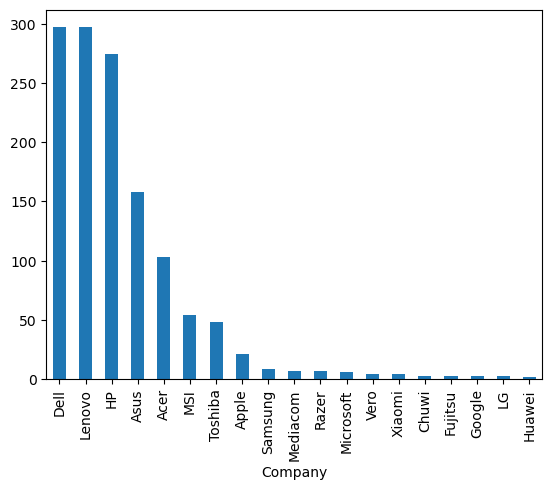

In [12]:
df['Company'].value_counts().plot(kind='bar')

In [13]:
df.groupby('Company')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Company,,,,,,,,
Acer,103.0,33394.615969,20015.770207,9270.7200,20539.4400,29783.5200,41265.3600,138474.720
Apple,21.0,83340.499886,29923.305164,47895.5232,61964.6400,71378.6832,104370.1920,152274.240
Asus,158.0,58830.143878,37428.679547,10224.4320,28624.6800,53946.0000,79293.9600,211788.000
Chuwi,3.0,16745.726400,6216.331527,13053.0672,13157.2296,13261.3920,18592.0560,23922.720
Dell,297.0,63193.755782,35854.308593,14646.6720,39164.5296,52480.8000,78438.8160,194972.832
Fujitsu,3.0,38841.120000,4022.551787,34578.7200,36976.3200,39373.9200,40972.3200,42570.720
Google,3.0,89386.080000,25216.998664,67932.0000,75497.7600,83063.5200,100113.1200,117162.720
HP,274.0,56891.044222,32900.827893,11135.5200,32820.3468,51495.1200,74005.9200,233845.920
Huawei,2.0,75870.720000,5651.197395,71874.7200,73872.7200,75870.7200,77868.7200,79866.720


<Axes: xlabel='TypeName'>

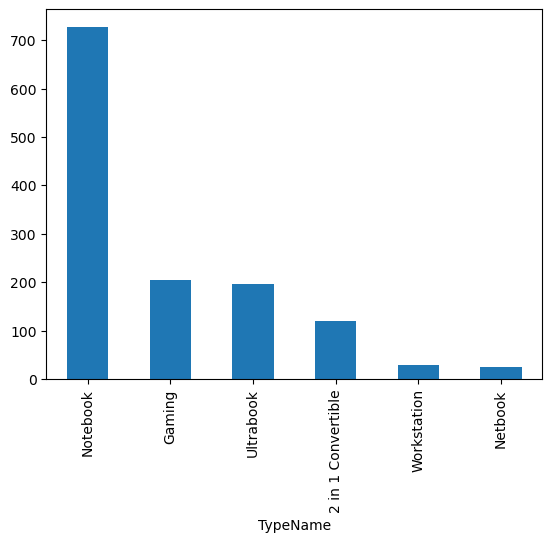

In [14]:
df['TypeName'].value_counts().plot(kind='bar')

In [15]:
df.groupby('TypeName')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
TypeName,,,,,,,,
2 in 1 Convertible,121.0,68326.360066,32682.637415,14652.00,42410.3472,63882.720,95850.72,150462.72
Gaming,205.0,92247.960187,43379.213607,37242.72,62284.3200,79536.384,117162.72,324954.72
Netbook,25.0,33898.440960,30970.912625,9270.72,14119.2000,18115.200,39640.32,101658.24
Notebook,727.0,41669.149113,23654.845738,10442.88,24988.5864,36816.480,52161.12,261018.72
Ultrabook,196.0,82489.713429,26075.362837,26586.72,61218.7200,79866.720,99580.32,165168.00
Workstation,29.0,121497.525683,37969.647335,72940.32,98834.4000,110017.872,130269.60,233845.92


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float32
 10  Price             1303 non-null   float64
dtypes: float32(1), float64(2), int32(1), object(7)
memory usage: 101.9+ KB


In [17]:
df.groupby('Inches')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Inches,,,,,,,,
10.1,4.0,26550.356400,7343.277200,16996.3200,23389.9200,27385.9200,30546.3564,34433.2656
11.3,1.0,69210.720000,NaN,69210.7200,69210.7200,69210.7200,69210.7200,69210.7200
11.6,33.0,20971.734545,9740.330928,9270.7200,14332.3200,18594.7200,25521.1200,51095.5200
12.0,6.0,68193.072000,6761.511200,61964.6400,63368.5680,67702.8960,68984.2800,80452.8000
12.3,5.0,65438.496000,37535.115265,23922.7200,35111.5200,67932.0000,83063.5200,117162.7200
12.5,39.0,84368.511138,21355.493321,35644.3200,72940.3200,84395.5200,94572.0000,165168.0000
13.0,2.0,75870.720000,5651.197395,71874.7200,73872.7200,75870.7200,77868.7200,79866.7200
13.3,164.0,70985.921883,26715.979474,10442.8800,50562.7200,70276.3200,88165.0800,149130.7200
13.5,6.0,85903.788000,31884.406736,52693.9200,61365.2400,83622.9600,98601.9660,137941.9200


<Axes: xlabel='Inches', ylabel='Price'>

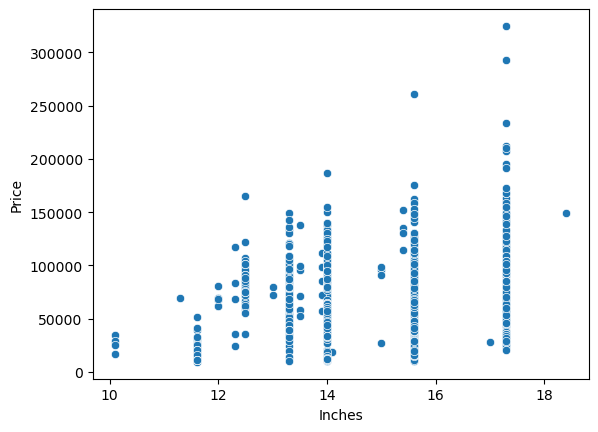

In [18]:
sns.scatterplot(data=df,x='Inches',y='Price')

Feature Engineering - Memory

In [19]:
df['Memory'].value_counts()

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
1TB SSD                           14
512GB SSD +  1TB HDD              14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
64GB SSD                       

In [20]:
df[['memory1','memory2']]=df['Memory'].str.split('+',expand=True)

In [21]:
df['memory1']=df['memory1'].str.strip()

df['memory2']=df['memory2'].str.strip()

In [22]:
df[['memory_size1','memory_type1']]=df['memory1'].str.split(' ',n=1,expand=True)

In [23]:
df[['extra_memory_size','extra_memory_type']]=df['memory2'].str.split(' ',n=1,expand=True)

In [24]:
df.drop(columns=['Memory','memory1','memory2'],axis=1,inplace=True)

In [25]:
def convert(x):
    
    
    if pd.isna(x):
        return 0 
    x = str(x).strip()       # Make sure it's a string
    
    if 'TB' in x:
        return float(x.replace('TB',''))*1024
    elif 'GB' in x :
        return float(x.replace('GB',''))
    else :
        return float(x)
    


In [26]:
df['Memory_size1']=df['memory_size1'].apply(convert)

In [27]:
df['extra_memory']=df['extra_memory_size'].apply(convert)

In [28]:
df.drop(columns=['memory_size1','extra_memory_size'],axis=1,inplace=True)

In [29]:
df['SSD'] = np.where(df['memory_type1']=='SSD',df['Memory_size1'],0) + \
            np.where(df['extra_memory_type']=='SSD',df['extra_memory'],0)

df['HDD'] = np.where(df['memory_type1']=='HDD',df['Memory_size1'],0) + \
            np.where(df['extra_memory_type']=='HDD',df['extra_memory'],0)

df['Flash'] = np.where(df['memory_type1']=='Flash Storage',df['Memory_size1'],0) + \
              np.where(df['extra_memory_type']=='Flash Storage',df['extra_memory'],0)

df['Hybrid'] = np.where(df['memory_type1']=='Hybrid',df['Memory_size1'],0) + \
               np.where(df['extra_memory_type']=='Hybrid',df['extra_memory'],0)

In [30]:
df.drop(
[
'memory_type1',
'extra_memory_type',
'Memory_size1',
'extra_memory'
],
axis=1,
inplace=True
)

Feature Engineering - Gpu

In [31]:
df['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      281
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
Nvidia Quadro M500M          1
AMD Radeon R7 M360           1
Nvidia Quadro M3000M         1
Nvidia GeForce 960M          1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64

In [32]:
df['Gpu_brand']=df['Gpu'].apply(
    lambda x: x.split()[0]
)

In [33]:
df['Gpu_brand'].value_counts()

Gpu_brand
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

In [34]:
df['dedicated_gpu']=df['Gpu_brand'].apply(
    lambda x: 1 if x in ['Nvidia','AMD'] else 0
)

In [35]:
df['gpu_model']=df['Gpu'].str.extract(
    '(\d{3,4})'
)

In [36]:
df.drop(columns=['Gpu'],axis=1,inplace=True)

Feature Engineering - opearating system

In [37]:
df['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [38]:
def os_category(x):

    if 'Windows' in x:
        return 'Windows'

    elif 'Mac' in x or 'macOS' in x:
        return 'Mac'

    elif 'Linux' in x:
        return 'Linux'

    elif 'Chrome' in x:
        return 'Chrome'

    else:
        return 'Other'

df['os_type']=df['OpSys'].apply(os_category)

Feature Engineering - Cpu

In [39]:
df['Cpu'].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 118, dtype: int64

In [40]:
df['cpu_speed']=df['Cpu'].str.extract('(\d+\.?\d*GHz)')

In [41]:
df['temp']=df['Cpu'].str.replace('(\d+\.?\d*GHz)','',regex=True).str.strip()

In [42]:
df['cpu_model']=df['temp'].str.extract(
    '(\d{4,}\w*)$'
)

In [43]:
df['cpu_model'].value_counts()

cpu_model
7200U     193
7700HQ    147
7500U     136
6006U      81
8550U      73
         ... 
4405U       1
6560U       1
7210        1
4405Y       1
8800P       1
Name: count, Length: 63, dtype: int64

In [44]:
df['cpu_series']=df['temp'].str.replace('(\d{4,}\w*)$','',regex=True).str.strip()

In [45]:
df['cpu_series'].value_counts()

cpu_series
Intel Core i7                522
Intel Core i5                418
Intel Core i3                136
Intel Celeron Dual Core N     73
Intel Pentium Quad Core N     27
AMD A9-Series                 15
Intel Atom x5-Z               10
AMD A6-Series                  9
AMD A12-Series                 8
Intel Celeron Quad Core N      8
Intel Celeron Dual Core        7
Intel Core i7 7Y75             5
Intel Core M 6Y75              5
AMD E-Series                   5
AMD A10-Series                 4
AMD Ryzen                      4
AMD E-Series E2-               4
AMD A8-Series                  4
Intel Core M                   4
Intel Core M 6Y30              3
Intel Core i5 7Y54             3
Intel Atom X5-Z                2
AMD A6-Series A6-              2
AMD A10-Series A10-            2
Intel Xeon E3-1505M V6         2
AMD FX                         2
Intel Pentium Dual Core        2
Intel Core i5 7Y57             2
AMD A9-Series A9-              2
Intel Core M m3                1

In [46]:
def con(x):
    x=str(x).strip()
    if 'Intel Core i7' in x:
        return 'Intel Core i7'
    elif 'Intel Core i5' in x:
        return 'Intel Core i5'

    elif 'Intel Core i3' in x:
        return 'Intel Core i3'
    elif 'Intel Celeron Dual Core N' in x:
        return 'Intel Celeron Dual Core N'

    elif 'Intel Pentium Quad Core N' in x:
        return 'Intel Pentium Quad Core N'
    elif 'Intel' in x :
        return 'Other Intel'
    elif 'AMD' in x:
        return 'All AMD'
    else:
        return 'other'

        

In [47]:
df['cpu_series']=df['cpu_series'].apply(con)

In [48]:
df['cpu_series'].value_counts()

cpu_series
Intel Core i7                527
Intel Core i5                423
Intel Core i3                136
Intel Celeron Dual Core N     73
All AMD                       62
Other Intel                   54
Intel Pentium Quad Core N     27
other                          1
Name: count, dtype: int64

In [49]:
df.drop(columns=['OpSys','temp','Cpu'],axis=1,inplace=True)

In [50]:
df['cpu_speed']=df['cpu_speed'].str.replace('GHz','').astype(float)

In [51]:
df['cpu_model'].value_counts()

cpu_model
7200U     193
7700HQ    147
7500U     136
6006U      81
8550U      73
         ... 
4405U       1
6560U       1
7210        1
4405Y       1
8800P       1
Name: count, Length: 63, dtype: int64

Feature Engineering - ScreenResolution

In [52]:
df['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2304x1440                 6
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

In [53]:
df['TouchScreen']=df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)

<Axes: xlabel='TouchScreen', ylabel='Price'>

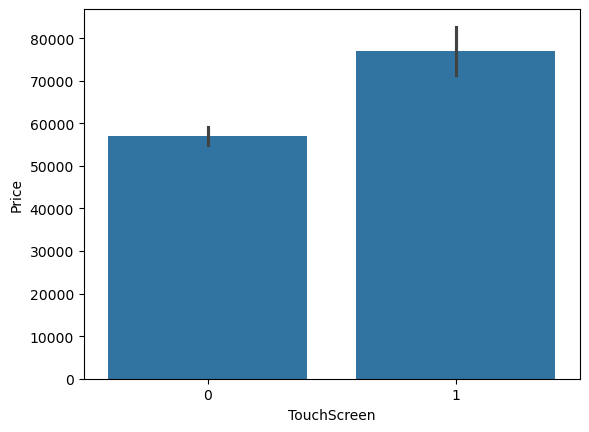

In [54]:
sns.barplot(data=df,x='TouchScreen',y='Price')

In [55]:
df['IPS']=df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)

<Axes: xlabel='IPS'>

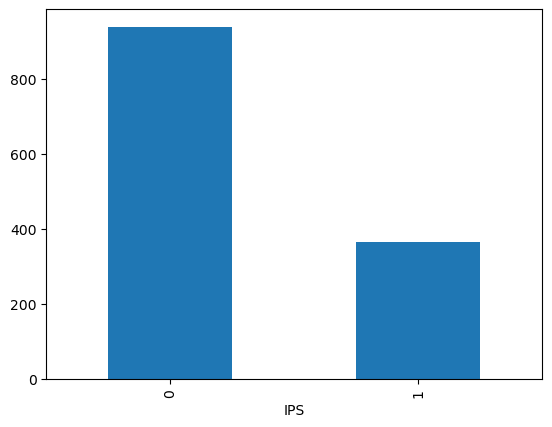

In [56]:
df['IPS'].value_counts().plot(kind='bar')

<Axes: xlabel='IPS', ylabel='Price'>

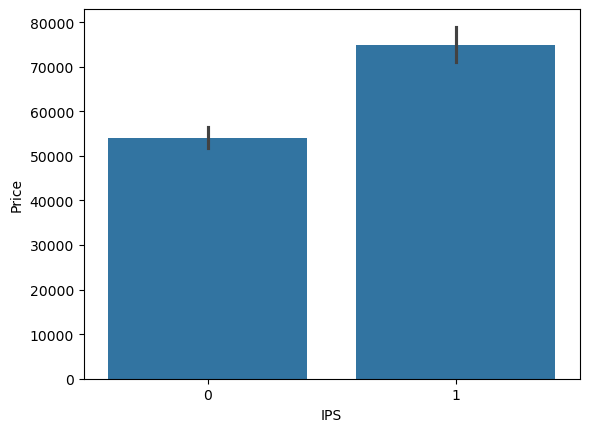

In [57]:
sns.barplot(data=df,x='IPS',y='Price')

In [58]:
new =df['ScreenResolution'].str.split('x',n=1,expand=True)

In [59]:
df['x_res']=new[0]
df['y_res']=new[1]

In [60]:
df['x_res'].value_counts()

x_res
Full HD 1920                                507
1366                                        281
IPS Panel Full HD 1920                      231
IPS Panel Full HD / Touchscreen 1920         53
Full HD / Touchscreen 1920                   47
1600                                         23
Touchscreen 1366                             16
Quad HD+ / Touchscreen 3200                  15
IPS Panel 4K Ultra HD 3840                   12
IPS Panel 4K Ultra HD / Touchscreen 3840     11
4K Ultra HD / Touchscreen 3840               10
4K Ultra HD 3840                              7
Touchscreen 2560                              7
IPS Panel 1366                                7
IPS Panel Retina Display 2304                 6
IPS Panel Quad HD+ / Touchscreen 3200         6
Touchscreen 2256                              6
IPS Panel Retina Display 2560                 6
IPS Panel Touchscreen 2560                    5
IPS Panel Retina Display 2880                 4
1440                              

In [61]:
df['x_res']=df['x_res'].str.split().str[-1]

In [62]:
df['x_res'].value_counts()

x_res
1920    846
1366    308
3840     43
2560     29
3200     27
1600     23
2304      6
2256      6
1440      4
2880      4
2400      4
2160      2
2736      1
Name: count, dtype: int64

In [63]:
df['x_res']=df['x_res'].astype('int')
df['y_res']=df['y_res'].astype('int')

In [64]:
df['ppi']=(((df['x_res']**2) + (df['y_res']**2))**0.5)/(df['Inches'])

In [65]:
df.drop(columns=['ScreenResolution','cpu_model','x_res','y_res','Inches'],axis=1,inplace=True)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        1303 non-null   object 
 1   TypeName       1303 non-null   object 
 2   Ram            1303 non-null   int32  
 3   Weight         1303 non-null   float32
 4   Price          1303 non-null   float64
 5   SSD            1303 non-null   float64
 6   HDD            1303 non-null   float64
 7   Flash          1303 non-null   float64
 8   Hybrid         1303 non-null   float64
 9   Gpu_brand      1303 non-null   object 
 10  dedicated_gpu  1303 non-null   int64  
 11  gpu_model      1240 non-null   object 
 12  os_type        1303 non-null   object 
 13  cpu_speed      1303 non-null   float64
 14  cpu_series     1303 non-null   object 
 15  TouchScreen    1303 non-null   int64  
 16  IPS            1303 non-null   int64  
 17  ppi            1303 non-null   float64
dtypes: float

EDA

<Axes: xlabel='Company'>

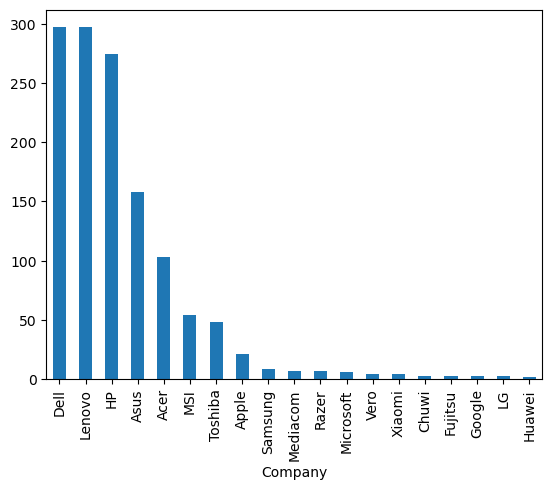

In [67]:
df['Company'].value_counts().plot(kind='bar')

<Axes: xlabel='TypeName'>

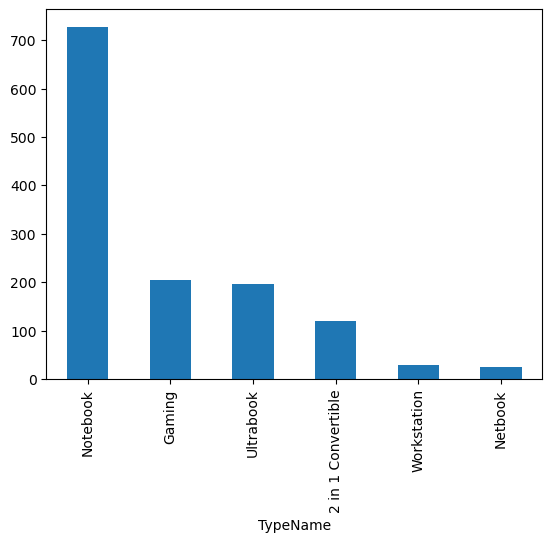

In [68]:
df['TypeName'].value_counts().plot(kind='bar')

In [69]:
df['Ram'].value_counts()

Ram
8     619
4     375
16    200
6      41
12     25
2      22
32     17
24      3
64      1
Name: count, dtype: int64

In [70]:
df['Ram'].skew()
# NO need to power tranformation because the Ram is descrete hardware specification not continous value
# scale robustscalar

np.float64(2.6868062634940526)

<Axes: xlabel='Ram', ylabel='Price'>

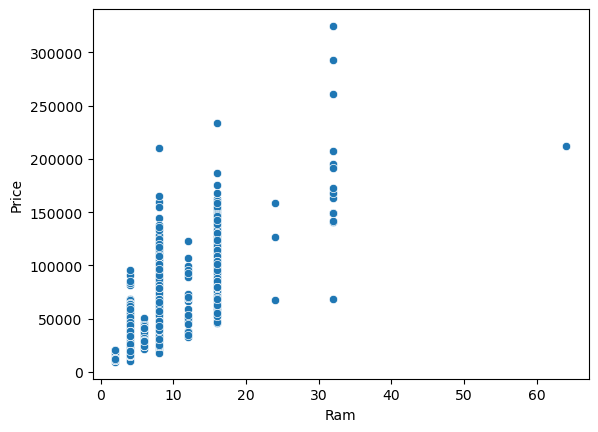

In [71]:
sns.scatterplot(x='Ram',y='Price',data=df)

1.1449629


<Axes: xlabel='Weight', ylabel='Density'>

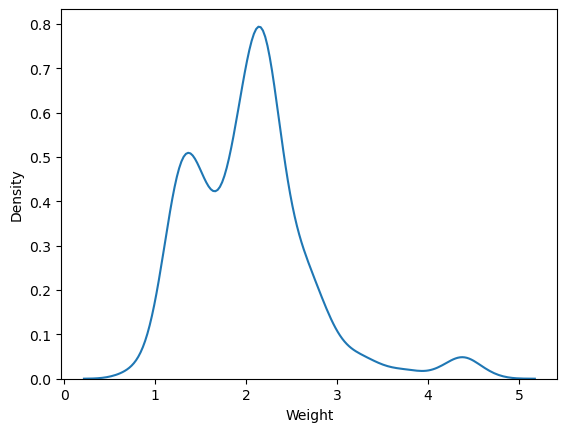

In [72]:
print(df['Weight'].skew())
sns.kdeplot(data=df,x='Weight')
# we can try the power transformation
# scale

In [73]:
print(df['SSD'].skew())
print(df['HDD'].skew())
print(df['Flash'].skew())
print(df['Hybrid'].skew())
# try the tranformations

1.4280753671389126
0.8956853983624706
11.091426168253198
10.515933786441838


Axes(0.125,0.11;0.775x0.77)


np.float32(1.1449629)

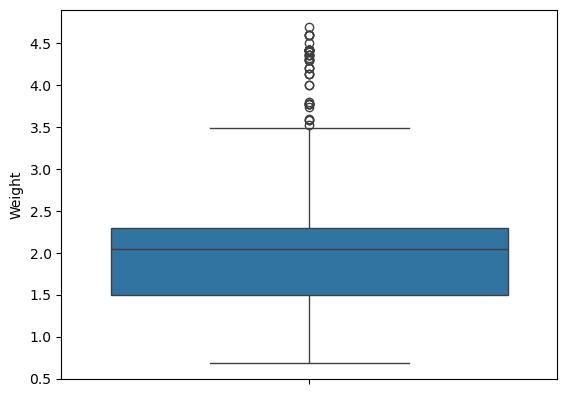

In [74]:
print(sns.boxplot(df['Weight']))
df['Weight'].skew()
# try the roubustscalar it has outliers try both stanadarscalar and robustscalar
#Try powertransformation

In [75]:
df['Gpu_brand'].value_counts()

Gpu_brand
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

<Axes: xlabel='Gpu_brand', ylabel='Price'>

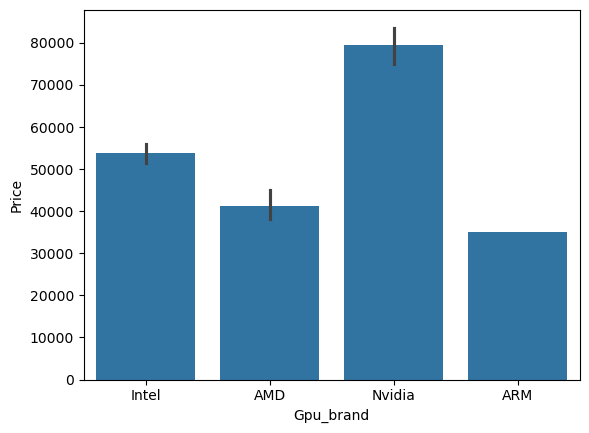

In [76]:
sns.barplot(data=df,x='Gpu_brand',y='Price')

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        1303 non-null   object 
 1   TypeName       1303 non-null   object 
 2   Ram            1303 non-null   int32  
 3   Weight         1303 non-null   float32
 4   Price          1303 non-null   float64
 5   SSD            1303 non-null   float64
 6   HDD            1303 non-null   float64
 7   Flash          1303 non-null   float64
 8   Hybrid         1303 non-null   float64
 9   Gpu_brand      1303 non-null   object 
 10  dedicated_gpu  1303 non-null   int64  
 11  gpu_model      1240 non-null   object 
 12  os_type        1303 non-null   object 
 13  cpu_speed      1303 non-null   float64
 14  cpu_series     1303 non-null   object 
 15  TouchScreen    1303 non-null   int64  
 16  IPS            1303 non-null   int64  
 17  ppi            1303 non-null   float64
dtypes: float

In [78]:
df['dedicated_gpu'].value_counts()

dedicated_gpu
0    723
1    580
Name: count, dtype: int64

In [79]:
df['gpu_model'].value_counts()
#  these is as the gpu model these is not the numaric contineous values  these is labels that why we can treated as categorical
# we can aapply the encoding imputation ordinal encoding 

gpu_model
620     357
520     205
1050    100
940      54
1060     49
530      42
500      40
400      37
930      32
1070     31
920      25
430      23
960      19
150      18
515      15
615      14
445      14
980      12
505      12
420      11
405       9
1200      9
640       8
950       7
1080      7
330       7
130       6
540       6
6000      5
580       5
550       5
970       5
440       5
2200      5
630       4
1000      4
965       4
510       4
4190      3
3000      2
460       2
650       2
560       2
5300      2
2000      2
555       1
455       1
5130      1
465       1
385       1
365       1
6150      1
315       1
360       1
860       1
Name: count, dtype: int64

<Axes: xlabel='os_type'>

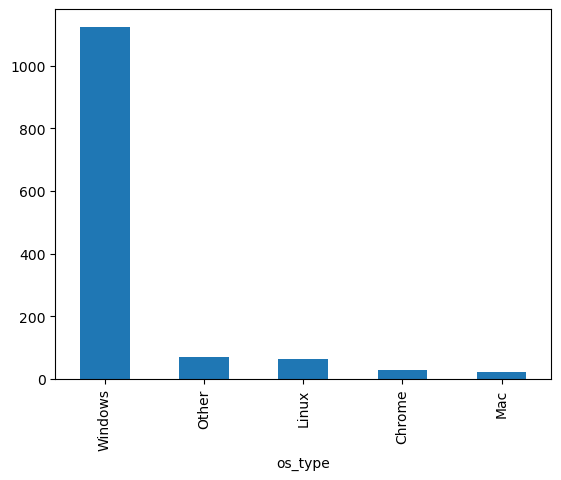

In [80]:
df['os_type'].value_counts().plot(kind='bar')

-0.832520289269616


<Axes: xlabel='cpu_speed', ylabel='Density'>

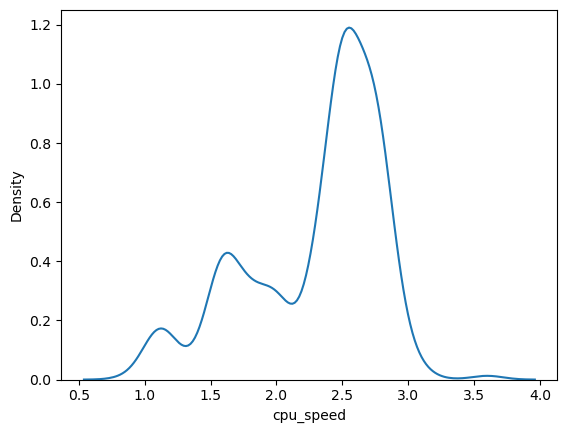

In [81]:
print(df['cpu_speed'].skew())
sns.kdeplot(df['cpu_speed'])
# no need the any transformations only scale

<Axes: xlabel='cpu_series'>

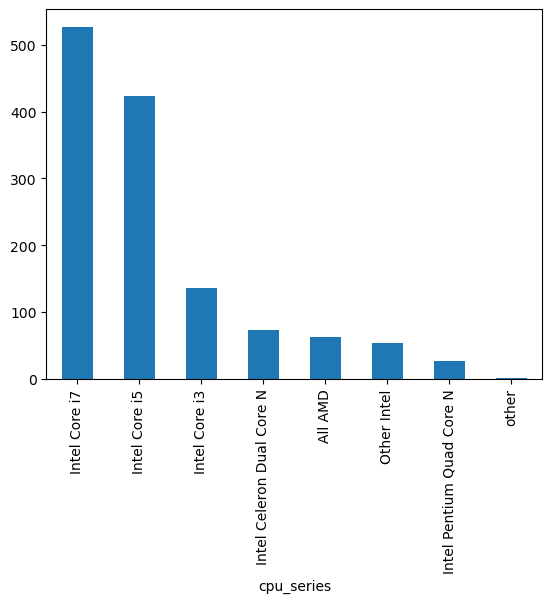

In [82]:
df['cpu_series'].value_counts().plot(kind='bar')


In [83]:
df['TouchScreen'].value_counts()

TouchScreen
0    1111
1     192
Name: count, dtype: int64

In [84]:
df['IPS'].value_counts()

IPS
0    938
1    365
Name: count, dtype: int64

2.02401367123033


<Axes: ylabel='ppi'>

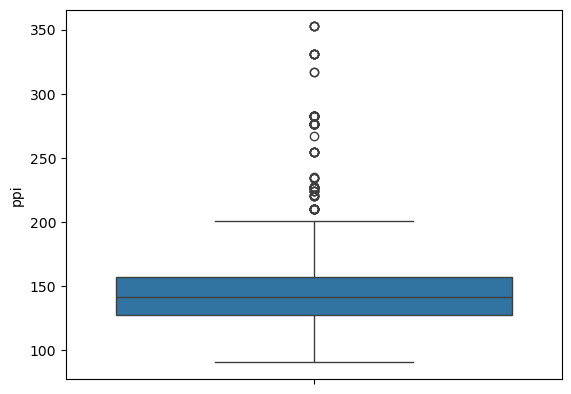

In [85]:
print(df['ppi'].skew())
sns.boxplot(df['ppi'])
#  keep outliers because they have meanigfull apply the mathematical transformations

<Axes: xlabel='ppi', ylabel='Price'>

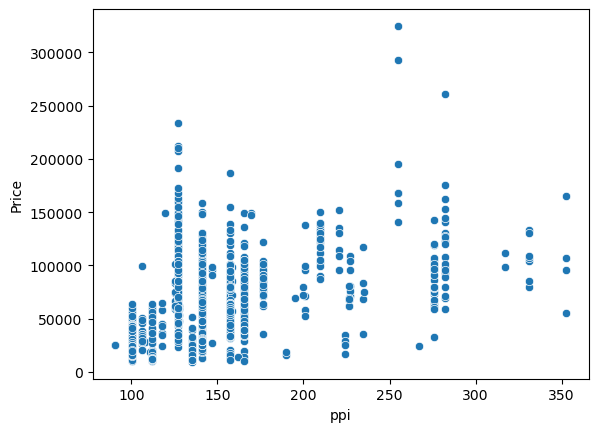

In [86]:
sns.scatterplot(x='ppi',y='Price',data=df)

Train Test splite

In [110]:
from sklearn.model_selection import train_test_split,cross_val_score
import numpy as np
x=df.drop(columns=['Price'],axis=1)
y=np.log1p(df['Price'])
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,shuffle=True,random_state=42)

In [88]:
df.isnull().sum()

Company           0
TypeName          0
Ram               0
Weight            0
Price             0
SSD               0
HDD               0
Flash             0
Hybrid            0
Gpu_brand         0
dedicated_gpu     0
gpu_model        63
os_type           0
cpu_speed         0
cpu_series        0
TouchScreen       0
IPS               0
ppi               0
dtype: int64

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        1303 non-null   object 
 1   TypeName       1303 non-null   object 
 2   Ram            1303 non-null   int32  
 3   Weight         1303 non-null   float32
 4   Price          1303 non-null   float64
 5   SSD            1303 non-null   float64
 6   HDD            1303 non-null   float64
 7   Flash          1303 non-null   float64
 8   Hybrid         1303 non-null   float64
 9   Gpu_brand      1303 non-null   object 
 10  dedicated_gpu  1303 non-null   int64  
 11  gpu_model      1240 non-null   object 
 12  os_type        1303 non-null   object 
 13  cpu_speed      1303 non-null   float64
 14  cpu_series     1303 non-null   object 
 15  TouchScreen    1303 non-null   int64  
 16  IPS            1303 non-null   int64  
 17  ppi            1303 non-null   float64
dtypes: float

In [90]:
cat_attribute=['Company','TypeName','Gpu_brand','os_type','cpu_series']
binary_attribute=['dedicated_gpu','TouchScreen','IPS']
gpu_model_attribute=['gpu_model']
only_scale=['Ram','cpu_speed']
num_attribute=['Weight','SSD','HDD','Flash','Hybrid','ppi']


In [243]:
from sklearn.preprocessing import (KBinsDiscretizer,RobustScaler,MaxAbsScaler,OrdinalEncoder,OneHotEncoder,PowerTransformer)
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score,root_mean_squared_error
from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge

In [92]:
cat_pipline=Pipeline([
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('encode',OneHotEncoder(drop='first',handle_unknown='ignore'))
])

In [93]:
binary_pipeline=Pipeline(
    [
        ('impute',SimpleImputer(strategy='most_frequent')),

    ]
)

In [94]:
gpu_model_pipeline=Pipeline(
    [
        ('impute',SimpleImputer(strategy='most_frequent')),
        ('encode',OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ))
    ]
)

In [95]:
only_scale_pipline=Pipeline(
    [
        ('impute',SimpleImputer(strategy='most_frequent')),
        ('scale',RobustScaler())
    ]
)

In [96]:
num_pipline=Pipeline(
    [
        ('impute',KNNImputer(n_neighbors=5,weights='uniform',add_indicator=True)),
        ('powertranfomer',PowerTransformer(method='yeo-johnson')),
        ('Scale',RobustScaler())
    ]
)

In [97]:
preprocessing=ColumnTransformer(
    [
        ('cat',cat_pipline,cat_attribute),
        ('binary',binary_pipeline,binary_attribute),
        ('gpu_model',gpu_model_pipeline,gpu_model_attribute),
        ('onlya-scale',only_scale_pipline,only_scale),
        ('num_attribute',num_pipline,num_attribute)
    ],
    remainder='passthrough'
)

In [253]:
# full_pipeline=Pipeline(
#     [
#         ('preprocessing',preprocessing),
#         # ('model',LinearRegression())
#         ('model',Ridge(alpha=0.1))
    
  
#     ]
# )

In [254]:
full_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Company', 'TypeName',
                                                   'Gpu_brand', 'os_type',
                                                   'cpu_series']),
                                                 ('binary',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='mos...
                                                  ['gpu_model']),
                                                 ('onlya-scale',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scale',
                                                                   RobustScaler())]),
                                                  ['Ram', 'cpu_speed']),
                                                 ('num_attribute',
                                                  Pipeline(steps=[('impute',
                                                                   KNNImputer(add_indicator=True)),
                                                                  ('powertranfomer',
                                                                   PowerTransformer()),
                                                                  ('Scale',
                                                                   RobustScaler())]),
                                                  ['Weight', 'SSD', 'HDD',
                                                   'Flash', 'Hybrid',
                                                   'ppi'])])),
                ('model', Ridge(alpha=0.1))])

In [231]:
y_pred=full_pipeline.predict(x_test)


In [232]:
r2=r2_score(y_test,y_pred)

In [233]:
full_pipeline[-1].coef_

array([ 0.2659445 ,  0.11729984, -0.37931237,  0.19018555,  0.0726286 ,
        0.49207606,  0.21684561,  0.03865593,  0.44476886,  0.13543022,
        0.15760322, -0.49097474,  0.31607926,  0.38341332,  0.26057415,
        0.2825521 , -0.4759447 ,  0.14776246, -0.13642891, -0.2424329 ,
       -0.21248087,  0.02129213,  0.32770128,  0.06549581,  0.04202115,
        0.13131457, -0.03325457,  0.2659445 , -0.17791026,  0.1198882 ,
       -0.19239685,  0.08217336,  0.34402095,  0.38335609, -0.02498546,
        0.15412124,  0.06549581, -0.10751696, -0.03292731,  0.05091194,
       -0.00253462,  0.1180021 ,  0.0857947 ,  0.01318984,  0.33096745,
        0.16129689,  0.00246544,  0.02207928,  0.07749141])

In [234]:
full_pipeline[-1].intercept_

np.float64(10.49005552119752)

In [235]:
k=full_pipeline[0].transform(x_train).shape[-1]

In [236]:
n=x_train.shape[0]

In [237]:
r2_ad=1-(((1-r2)*(n-1))/(n-1-k))

In [238]:
r2_ad

0.8457419783478888

In [239]:
r2

0.8530029226907836

In [240]:
# y_pred=np.exp(full_pipeline.predict(x_test))
# y_true=np.exp(y_test)
print(root_mean_squared_error(y_test,y_pred))

0.22824701965949656


In [255]:
# score=cross_val_score(
#     full_pipeline,
#     x_train,
#     y_train,
#     cv=5,
#     scoring='r2'
# )

C:\Users\dnyan\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\dnyan\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [256]:
score.mean()

np.float64(0.8310507276875809)

In [257]:
for a in [0.01,0.1,1,10,100]:
    full_pipeline=Pipeline(
        [
            ('preprocessing',preprocessing),
            ('model',Ridge(a))
        ]
    )
    score=cross_val_score(

        full_pipeline,
        x_train,
        y_train,
        cv=5,
        scoring='r2'
     )
    print(a,score.mean())

C:\Users\dnyan\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\dnyan\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


0.01 0.8306097955474782


C:\Users\dnyan\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\dnyan\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


0.1 0.8310507276875809


C:\Users\dnyan\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\dnyan\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


1 0.8320034386946986


C:\Users\dnyan\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\dnyan\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


10 0.8251477675567693
100 0.7848983842846038


C:\Users\dnyan\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\dnyan\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
